# Business Understanding

## Project Domain

Proyek ini berada di domain manufaktur dan industri berbasis data sensor. Fokus utamanya adalah bagaimana memanfaatkan data mesin secara real-time untuk memprediksi kerusakan mesin sebelum terjadi (predictive maintenance), sehingga bisa menghindari downtime yang mahal dan meningkatkan efisiensi operasional.

## Problem Statements

Dalam proses produksi, kegagalan mesin yang tidak terduga dapat menyebabkan gangguan serius pada jalannya operasi, menyebabkan keterlambatan, kerugian finansial, dan bahkan risiko keselamatan. Saat ini, banyak perusahaan masih mengandalkan pemeliharaan berkala yang tidak selalu efektif. Oleh karena itu, diperlukan sistem yang dapat memprediksi kemungkinan kerusakan mesin secara otomatis dan tepat waktu berdasarkan data sensor.

## Goals

1.Membangun model prediksi yang dapat mengklasifikasikan apakah sebuah mesin akan mengalami kegagalan (failure) atau tidak, berdasarkan data sensor dan log operasional.

2.Mengidentifikasi fitur-fitur penting (misalnya: suhu, tekanan, kecepatan rotasi, dll.) yang paling berkontribusi terhadap kerusakan mesin.

3.Memberikan rekomendasi untuk pemeliharaan preventif berdasarkan hasil prediksi model.

## Solution Statements

Proyek ini akan mengembangkan solusi berbasis machine learning classification, menggunakan data historis mesin (seperti suhu, kelembaban, tekanan, dan jam operasi) untuk memprediksi kemungkinan terjadinya kerusakan. Dengan menggunakan algoritma seperti Random Forest, Logistic Regression, atau XGBoost, sistem akan belajar dari pola-pola kegagalan sebelumnya dan memberikan prediksi secara otomatis, memungkinkan tindakan perbaikan yang lebih cepat dan lebih hemat biaya.

# Data Understanding

## Import data dari kaggle

In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nadiabintang","key":"b6f7d96de203695dd5ccd69ce037b12f"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [8]:
!kaggle datasets download -d ikjotsingh221/machine-failure-cleaned

Dataset URL: https://www.kaggle.com/datasets/ikjotsingh221/machine-failure-cleaned
License(s): other


In [9]:
!mkdir machine-failure-cleaned
!unzip machine-failure-cleaned.zip -d machine-failure-cleaned
!ls machine-failure-cleaned

Archive:  machine-failure-cleaned.zip
  inflating: machine-failure-cleaned/machine_failure_cleaned.csv  
machine_failure_cleaned.csv


## Import Library yang dibutuhkan

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf


from imblearn.over_sampling import SMOTE
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


## Exploratory Data Analysis

In [11]:
df = pd.read_csv("/content/machine-failure-cleaned/machine_failure_cleaned.csv")


In [12]:
df.head()

,Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,Machine failure
0,1551,42.8,0,0,0,0,0,0
1,1408,46.3,3,0,0,0,0,0
2,1498,49.4,5,0,0,0,0,0
3,1433,39.5,7,0,0,0,0,0
4,1408,40.0,9,0,0,0,0,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9815 entries, 0 to 9814
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Rotational speed [rpm]  9815 non-null   int64  
 1   Torque [Nm]             9815 non-null   float64
 2   Tool wear [min]         9815 non-null   int64  
 3   TWF                     9815 non-null   int64  
 4   HDF                     9815 non-null   int64  
 5   PWF                     9815 non-null   int64  
 6   OSF                     9815 non-null   int64  
 7   Machine failure         9815 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 613.6 KB


<ipython-input-14-e0db8626e1ab>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Machine failure', palette='coolwarm')


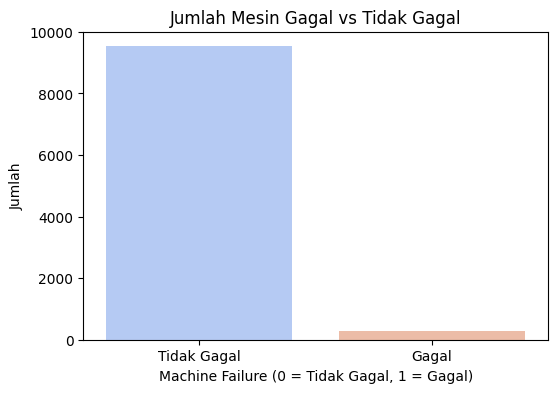

In [14]:
#COUNT PLOT ( Jumlah Mesin Gagal vs Tidak Gagal )
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Machine failure', palette='coolwarm')
plt.title('Jumlah Mesin Gagal vs Tidak Gagal')
plt.xlabel('Machine Failure (0 = Tidak Gagal, 1 = Gagal)')
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Tidak Gagal', 'Gagal'])
plt.show()

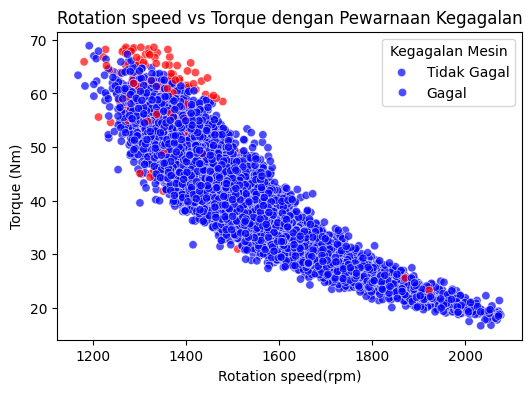

In [15]:
# SCATTER PLOT (Torsi vs Tool Wear) Berwarna Berdasarkan Status Kegagalan
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure',
                palette={0:'blue',1:'red'}, alpha=0.7)
plt.title('Rotation speed vs Torque dengan Pewarnaan Kegagalan')
plt.xlabel('Rotation speed(rpm)')
plt.ylabel('Torque (Nm)')
plt.legend(title='Kegagalan Mesin', labels=['Tidak Gagal','Gagal'])
plt.show()

<ipython-input-16-731c44d47168>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Machine failure', y='Torque [Nm]', palette='Set2')


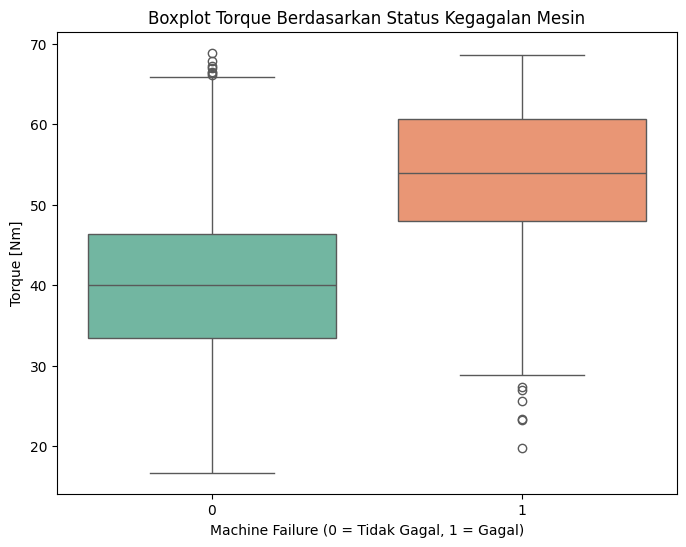

In [16]:
# BOX PLOT ( Torque Berdasarkan Status Kegagalan Mesin )
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Machine failure', y='Torque [Nm]', palette='Set2')
plt.title('Boxplot Torque Berdasarkan Status Kegagalan Mesin')
plt.xlabel('Machine Failure (0 = Tidak Gagal, 1 = Gagal)')
plt.ylabel('Torque [Nm]')
plt.show()


<ipython-input-17-0a9e4ddbba7d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Machine failure', y='Tool wear [min]', palette='Set2')


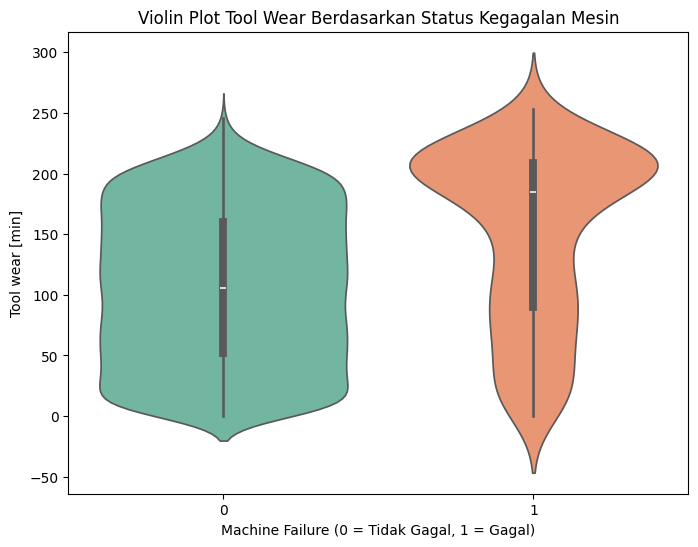

In [17]:
# VIOLIN PLOT (Tool Wear Berdasarkan Status Kegagalan Mesin )
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Machine failure', y='Tool wear [min]', palette='Set2')
plt.title('Violin Plot Tool Wear Berdasarkan Status Kegagalan Mesin')
plt.xlabel('Machine Failure (0 = Tidak Gagal, 1 = Gagal)')
plt.ylabel('Tool wear [min]')
plt.show()


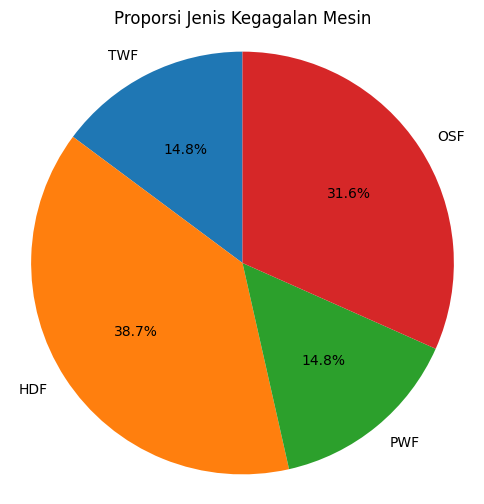

In [18]:
# PIE CHART ( Proporsi Jenis Kegagalan Mesin (TWF, HDF, PWF, OSF) )
failure_types = ['TWF', 'HDF', 'PWF', 'OSF']
failure_counts = df[failure_types].sum()

plt.figure(figsize=(6,6))
plt.pie(failure_counts, labels=failure_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proporsi Jenis Kegagalan Mesin')
plt.axis('equal')
plt.show()


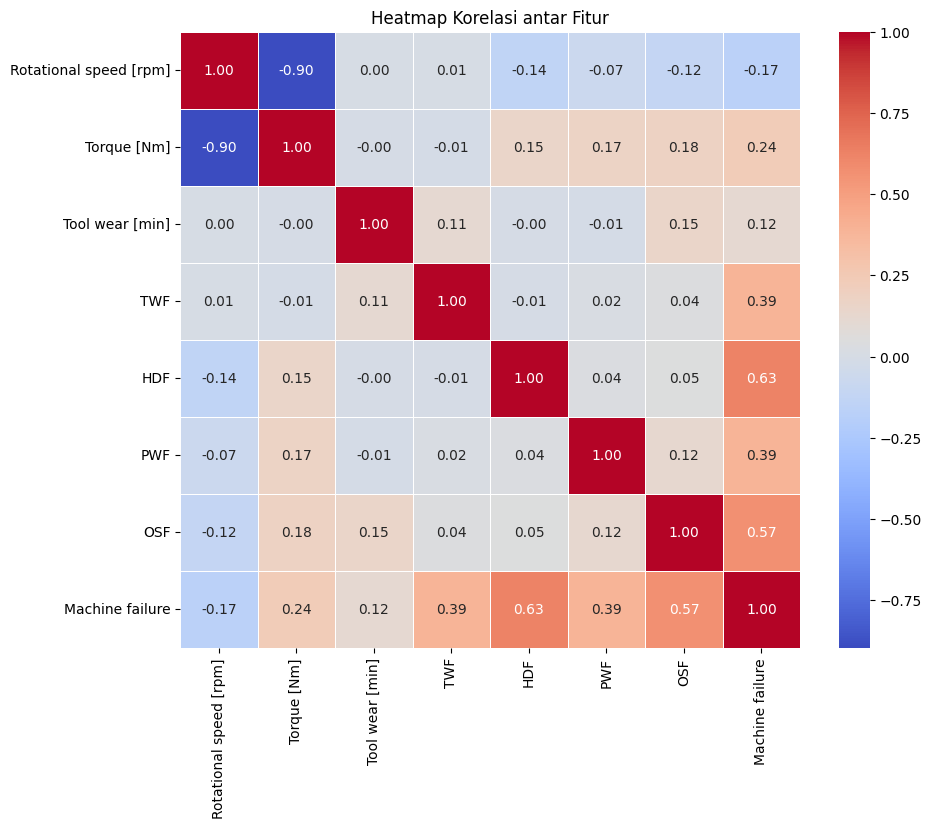

In [19]:
# HEATMAP ( Korelasi antar fitur )
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi antar Fitur')
plt.show()


# Data Preparation

In [48]:
# Data Preparation
if 'id' in df.columns:
    df = df.drop(columns=['id'])

In [49]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [50]:
# Pisahkan fitur dan target
X = df_encoded.drop(columns=["Machine failure"])
y = df_encoded["Machine failure"]


In [51]:
# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [52]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
# SMOTE untuk menangani ketidakseimbangan
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y_encoded)

In [54]:
# Split data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Modeling

In [55]:
# Membangun model ANN
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [57]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

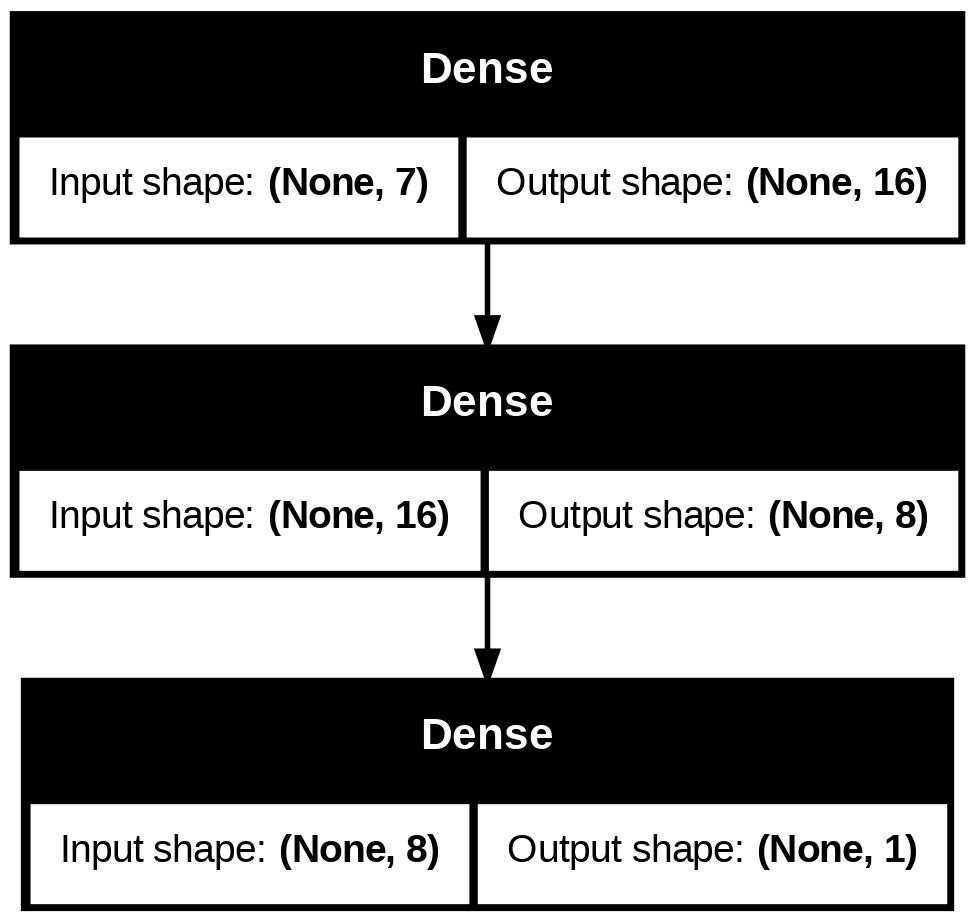

In [58]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [59]:
# Melatih model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8441 - loss: 0.3762 - val_accuracy: 0.9822 - val_loss: 0.0801
Epoch 2/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9825 - loss: 0.0788 - val_accuracy: 0.9822 - val_loss: 0.0787
Epoch 3/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9833 - loss: 0.0745 - val_accuracy: 0.9822 - val_loss: 0.0775
Epoch 4/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9846 - loss: 0.0695 - val_accuracy: 0.9822 - val_loss: 0.0773
Epoch 5/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9830 - loss: 0.0750 - val_accuracy: 0.9822 - val_loss: 0.0773
Epoch 6/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9842 - loss: 0.0703 - val_accuracy: 0.9822 - val_loss: 0.0770
Epoch 7/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9855 - loss: 0.0657 - val_accuracy: 0.9822 - val_loss: 0.0769
Epoch 8/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9821 - loss: 0.0766 - val_accuracy: 0.

# Evaluation

In [61]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9824 - loss: 0.0648
Akurasi Model: 0.9822
Loss Model: 0.0634


In [62]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0.5, 1.0, 'Accuracy')

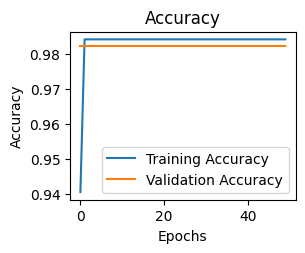

In [63]:

# Plot grafik akurasi pelatihan dan validasi
plt.subplot(2, 2, 1)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

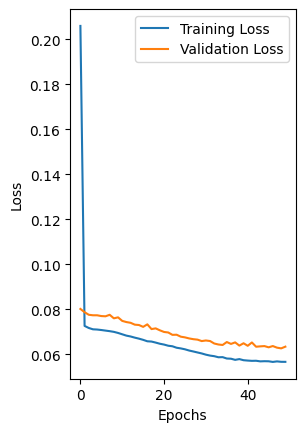

In [64]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


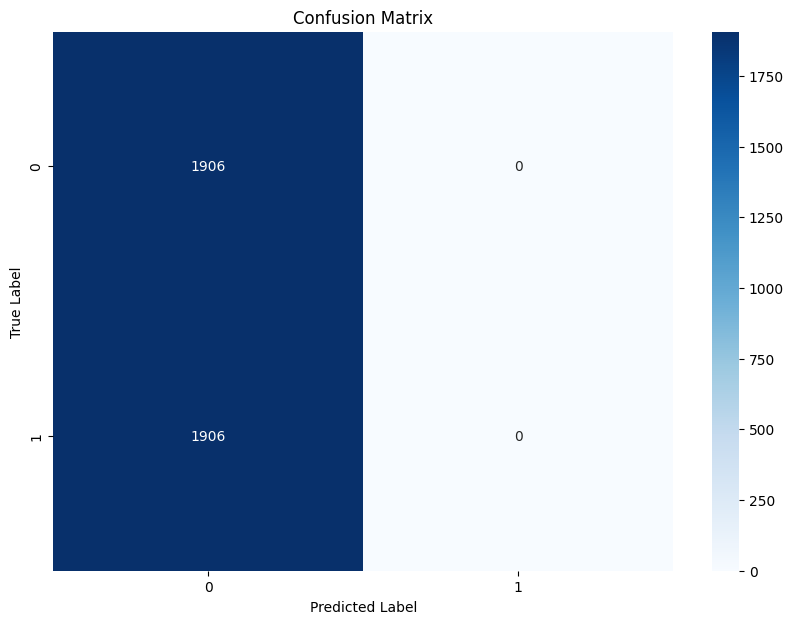

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67      1906
           1       0.00      0.00      0.00      1906

    accuracy                           0.50      3812
   macro avg       0.25      0.50      0.33      3812
weighted avg       0.25      0.50      0.33      3812



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [65]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [66]:
# Simulasi prediksi
new_data = np.array([[1500, 40.0, 5, 0, 0, 1, 0]])
new_data_scaled = scaler.transform(new_data)
prediction_prob = model.predict(new_data_scaled)
prediction = (prediction_prob > 0.5).astype(int)

if prediction[0][0] == 1:
    print("MESIN DIPREDIKSI GAGAL.")
else:
    print("MESIN DIPREDEKSI AMAN.")
print(f"Probabilitas gagal: {prediction_prob[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
MESIN DIPREDIKSI GAGAL.
Probabilitas gagal: 1.00


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [67]:
df['Machine failure'].value_counts()


,count
Machine failure,
0,9529
1,286


## Save Model

In [68]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('machine-failure-cleaned.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpawrtxhr4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137690048433808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137690048441296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137690048439952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137689984068560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137689984067600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137689984068176: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [69]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [70]:
from google.colab import files
files.download("scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
from google.colab import files

tflite_model_path = 'machine-failure-cleaned.tflite'
files.download(tflite_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>